# Exploratory Data Analysis

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

###  Business Problem - HR wants to predict the Employee Attrition

#### Load the dataset from CSV file and check first 5 records using head()

In [4]:
# Grabs the notebook's directory instead of relying on __file__
notebook_dir = os.getcwd() 

employee_df = pd.read_csv(notebook_dir+"/docs/HR-Employee-Attrition.csv")
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Analyse the numerical column values using describe method to find count of values, mean, Std Dev, min/max, quartiles

In [5]:
employee_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Missing Value Analysis

In [6]:
employee_df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [7]:
# Having a backup of the data frame
backup_df = employee_df.copy()

### Removing Unwanted Columns from the dataset

In [8]:
#Remove unwanted columns from dataset
employee_df.drop(["Over18","EmployeeCount","EmployeeNumber","StandardHours"],axis=1,inplace=True)

In [9]:
employee_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EnvironmentSatisfaction   1470 non-null   int64
 9   Gender                    1470 non-null   str  
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   str  
 14  JobSatisfaction           1470 non-null   int64
 15

## Target Variable Analysis

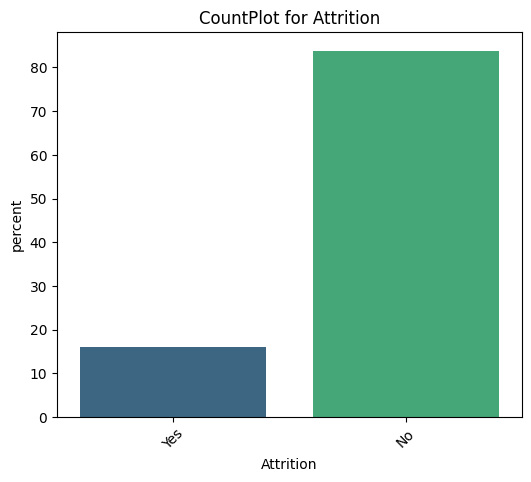

In [10]:
employee_df["Attrition"].value_counts(normalize=True)*100
plt.figure(figsize=(6, 5))
plt.xticks(rotation=45)
plt.title(f"CountPlot for Attrition")
sns.countplot(data=employee_df,x="Attrition",hue="Attrition",palette="viridis",stat="percent",legend="auto")
plt.show();

## Numerical Feature Analysis

In [11]:
#Getting the numerical columns
numeric_cols = employee_df.select_dtypes(include=np.number).columns
print(numeric_cols)

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='str')


In [12]:
numeric_cols_v1 =  ['Education','EnvironmentSatisfaction',  'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TrainingTimesLastYear',
       'WorkLifeBalance',  'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager']

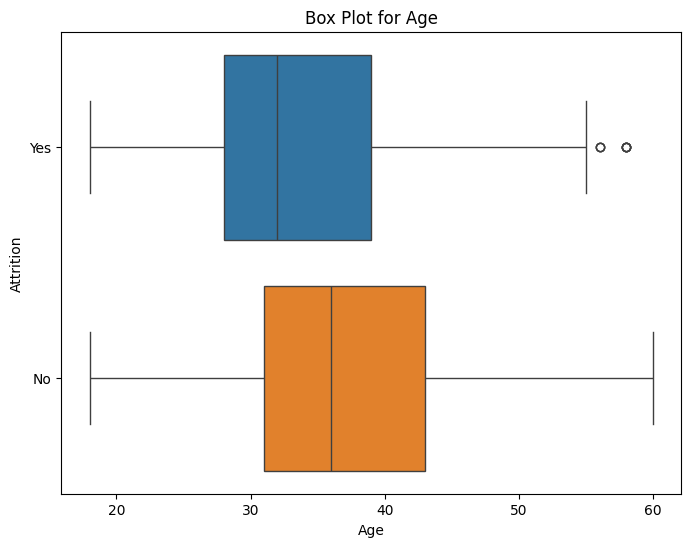

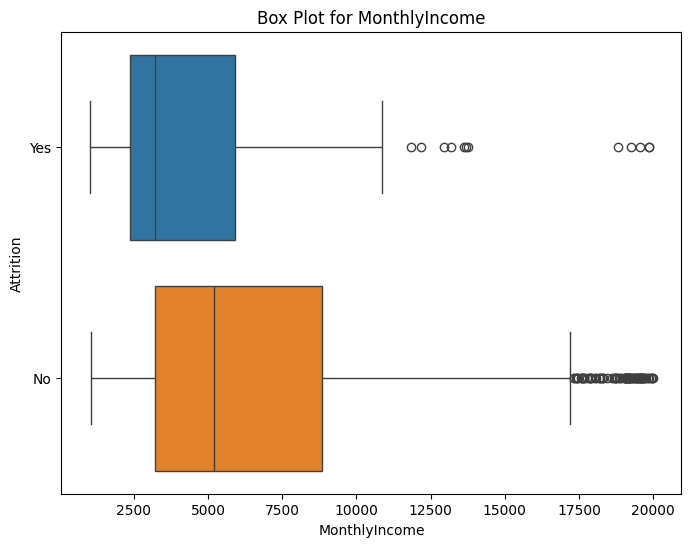

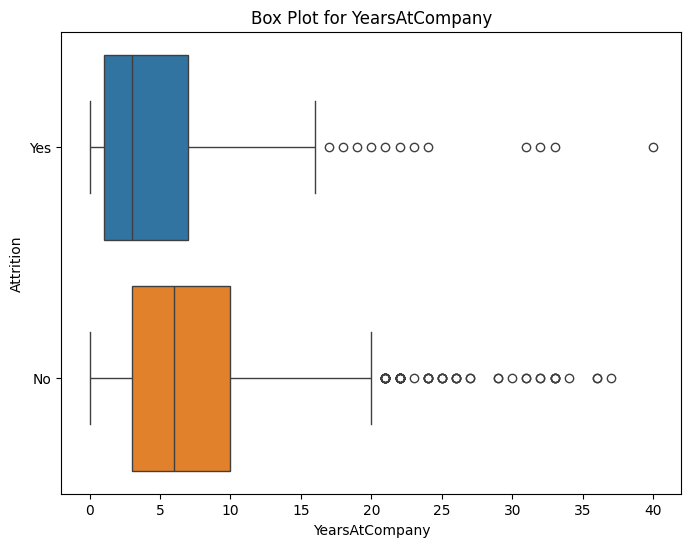

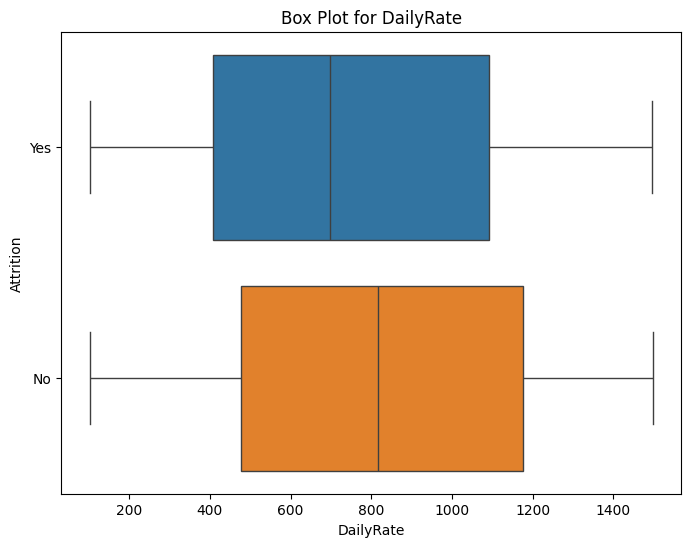

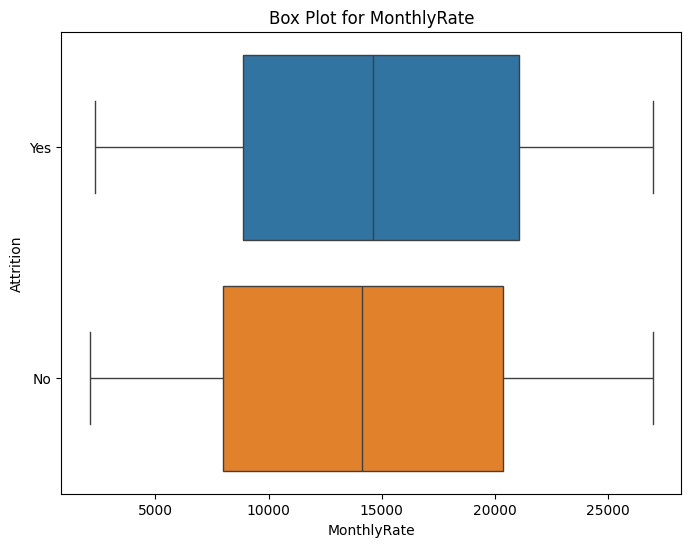

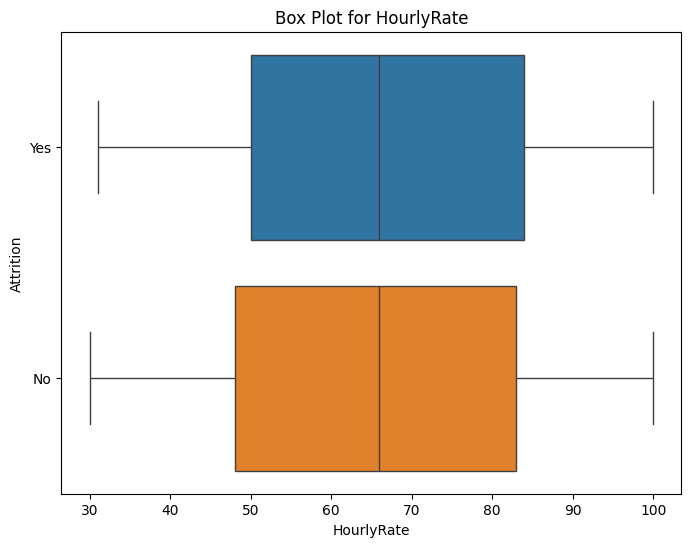

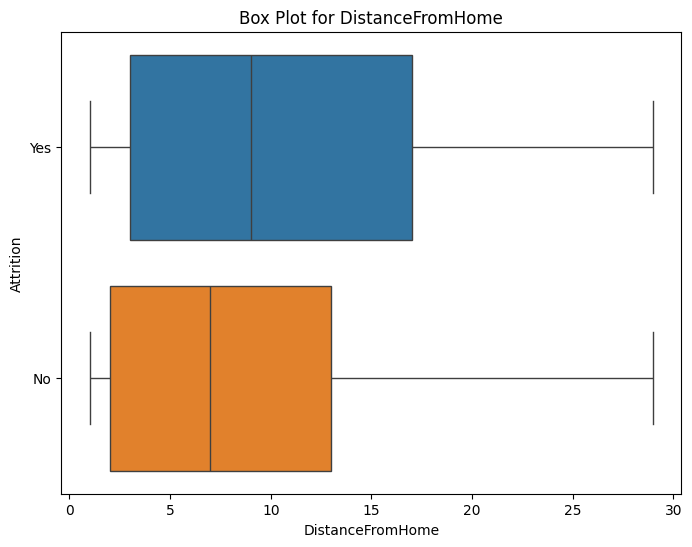

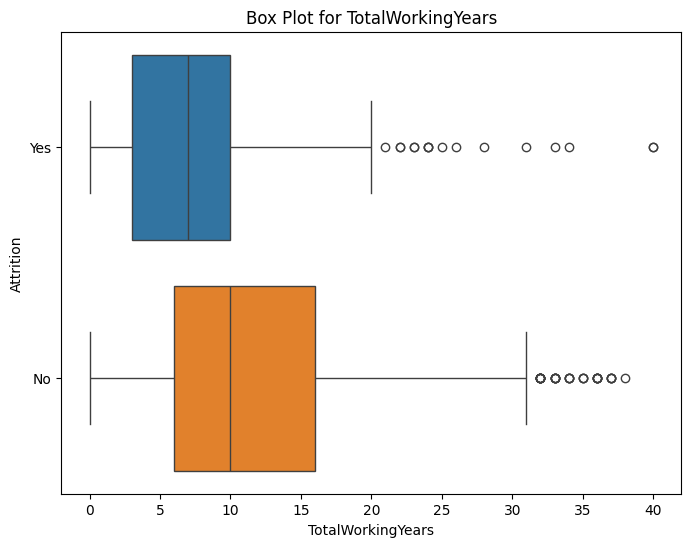

In [13]:
box_plot_list = ['Age','MonthlyIncome','YearsAtCompany','DailyRate','MonthlyRate','HourlyRate','DistanceFromHome','TotalWorkingYears']
for col in box_plot_list:
  plt.figure(figsize=(8, 6))
  #plt.xticks(rotation=45)
  plt.title(f"Box Plot for {col}")
  sns.boxplot(data=employee_df,x=col,y="Attrition",hue="Attrition")
  plt.show();

### Remaining Numerical Columns Analysis

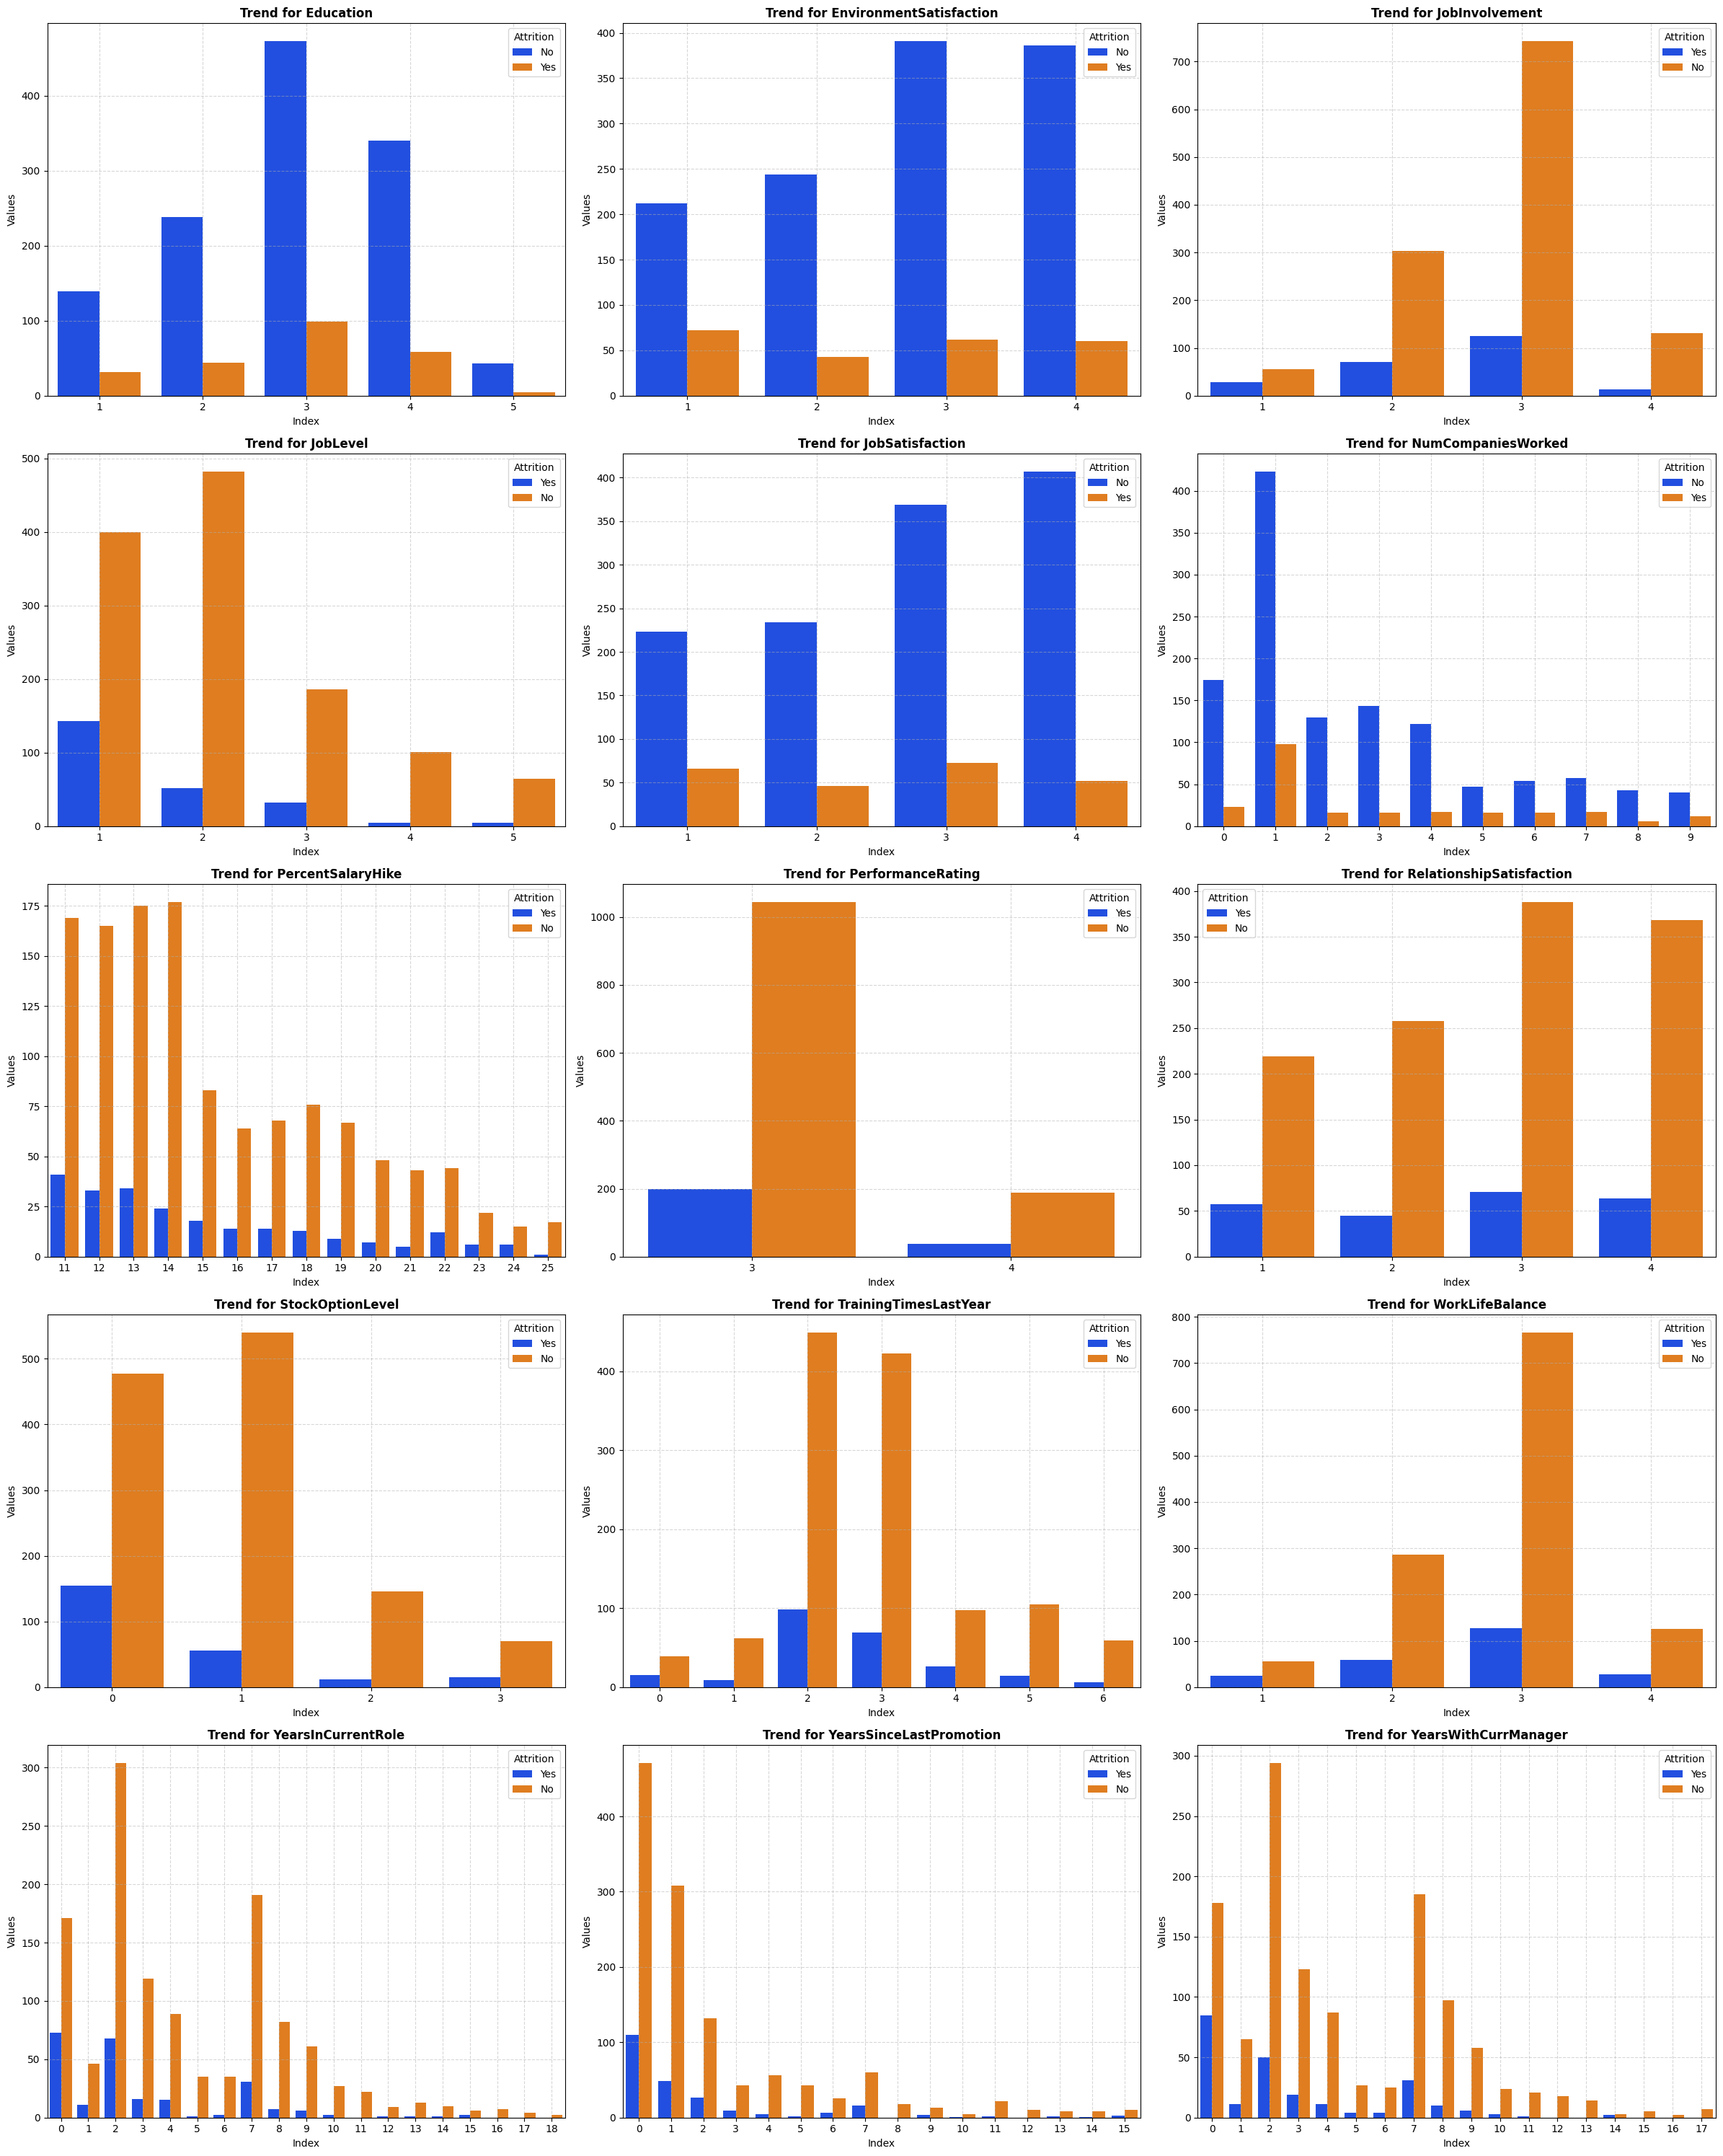

In [29]:
#  Initialize the grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(24, 30))

# Flatten the axes array for easy 1D iteration
axes_flat = axes.flatten()

#  Loop through columns and axes simultaneously
for index, col_name in enumerate(numeric_cols_v1):
    ax = axes_flat[index]
    
    # Generate the plot on the specific axis
    sns.countplot(data=employee_df,x=col_name,hue="Attrition",palette="bright", ax=ax)
    
    # Customize the individual subplot
    ax.set_title(f'Trend for {col_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Index', fontsize=10)
    ax.set_ylabel('Values', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

# Hide any unused/empty subplots in the grid
for remaining_index in range(len(numeric_cols_v1), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_index])

#  Optimize spacing and display
plt.tight_layout()
plt.show()

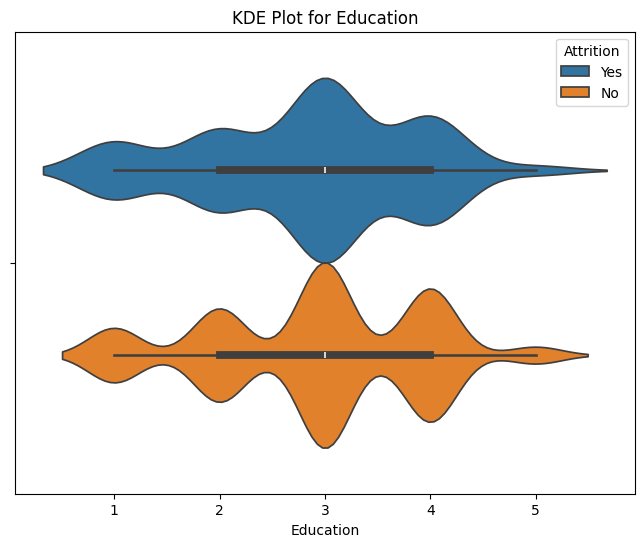

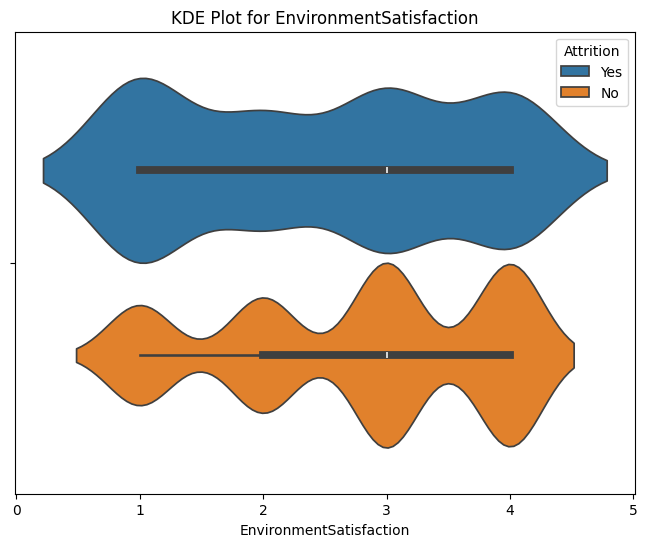

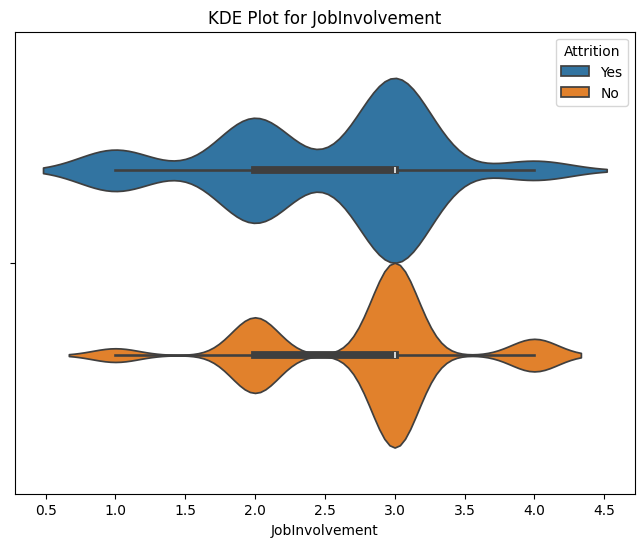

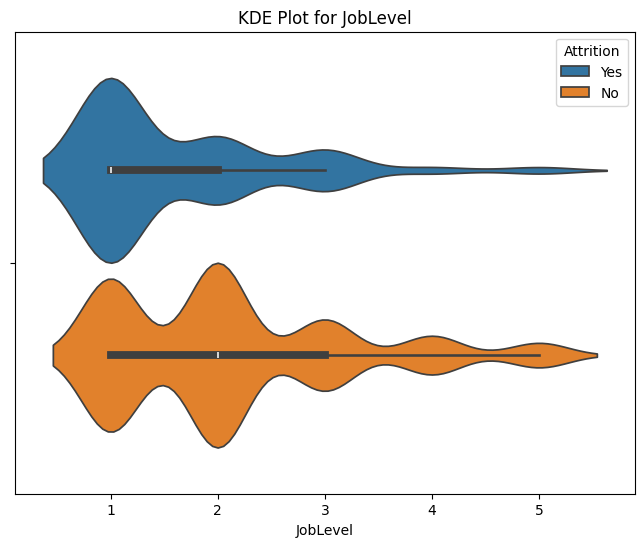

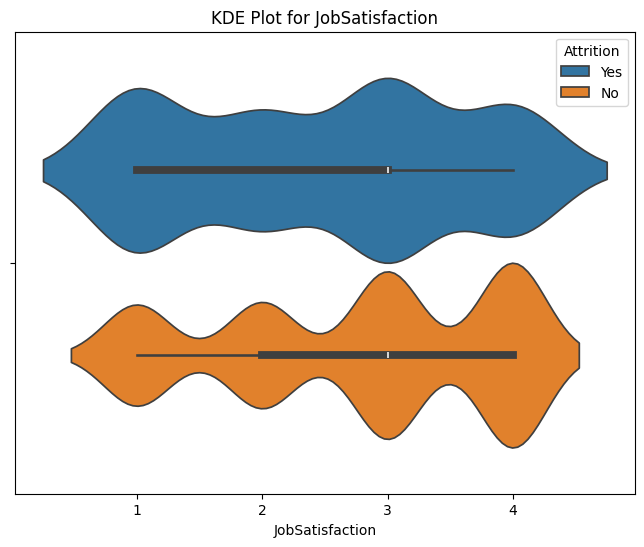

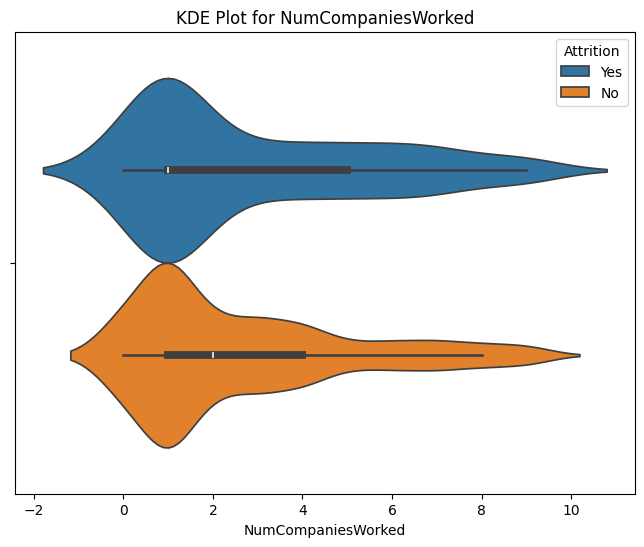

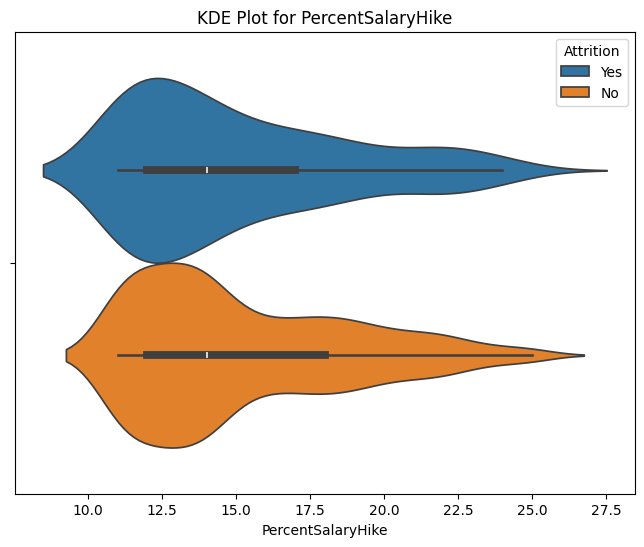

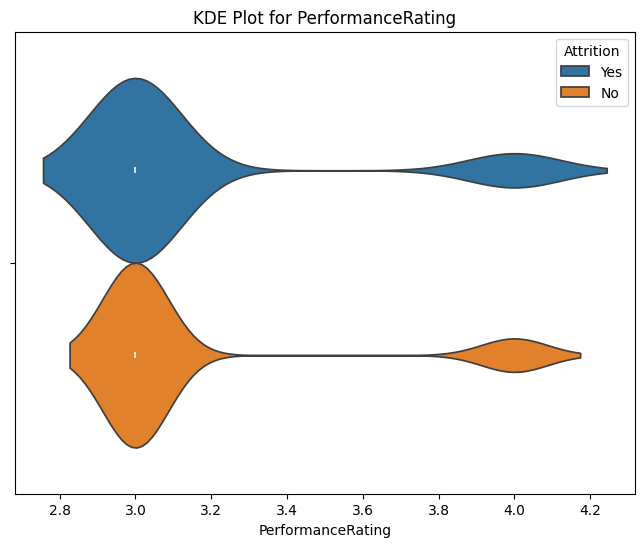

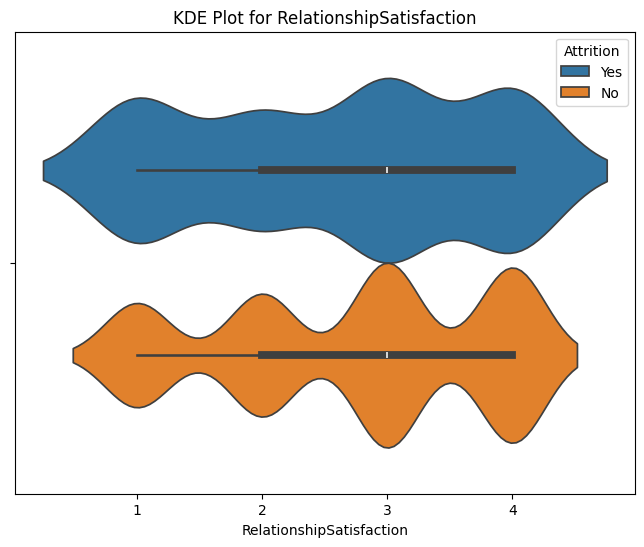

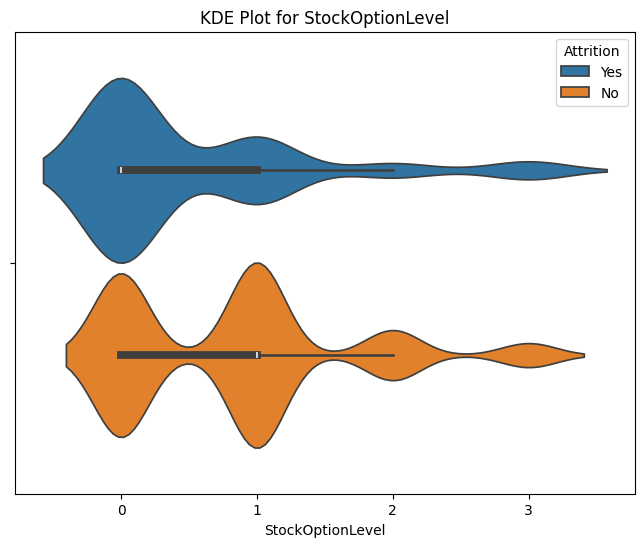

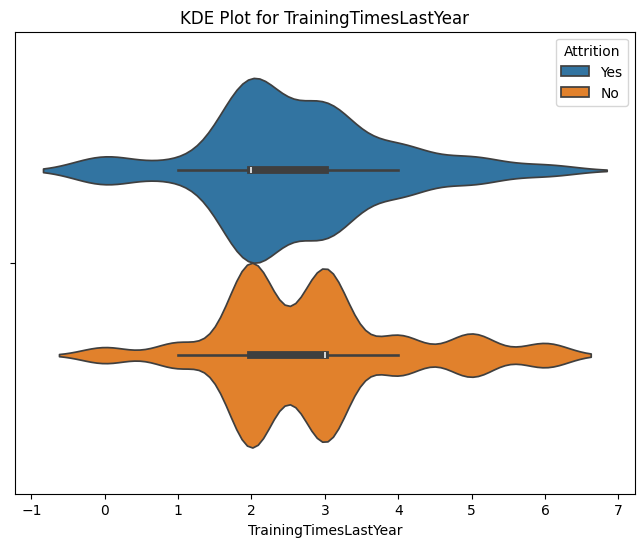

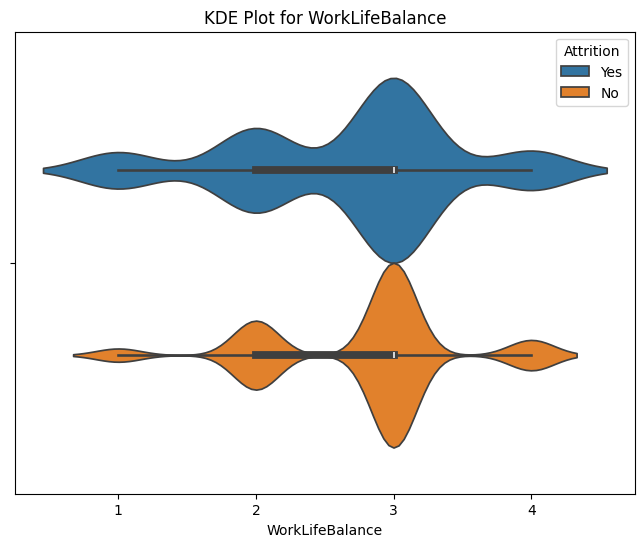

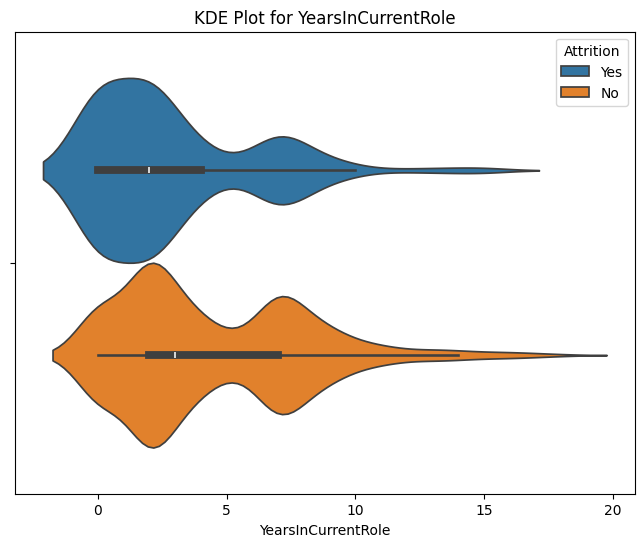

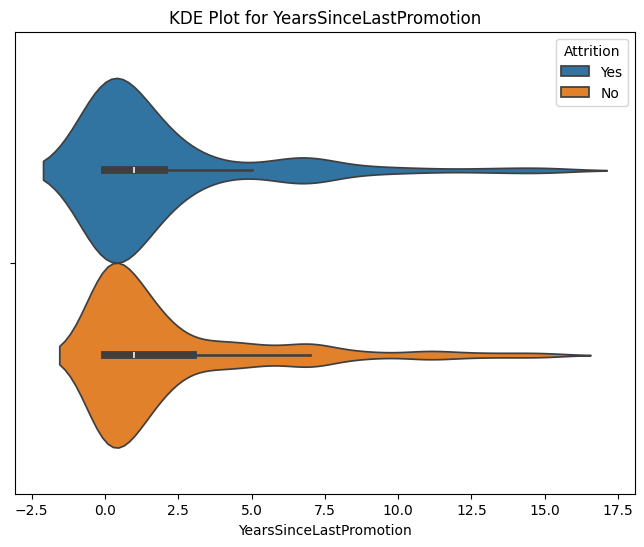

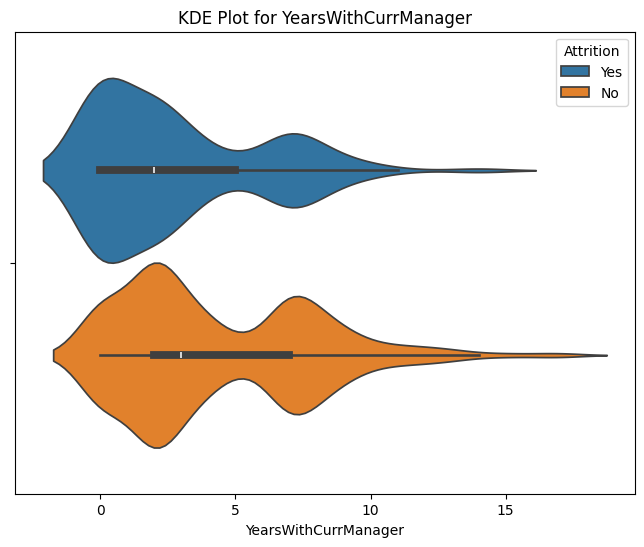

In [48]:
for col in numeric_cols_v1:
  plt.figure(figsize=(8, 6))
  #plt.xticks(rotation=45)
  plt.title(f"KDE Plot for {col}")
  sns.violinplot(data=employee_df,x=col,hue="Attrition")
  plt.show();

## Categorical Columns List

In [14]:
categorical_cols = employee_df.select_dtypes(exclude=np.number).columns.tolist()
#Categorical columns without Attrition (Target Variable)
cat_cols_without_attr = categorical_cols.copy()
cat_cols_without_attr.remove("Attrition")
print(cat_cols_without_attr)


['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


### Plots for Categorical Columns

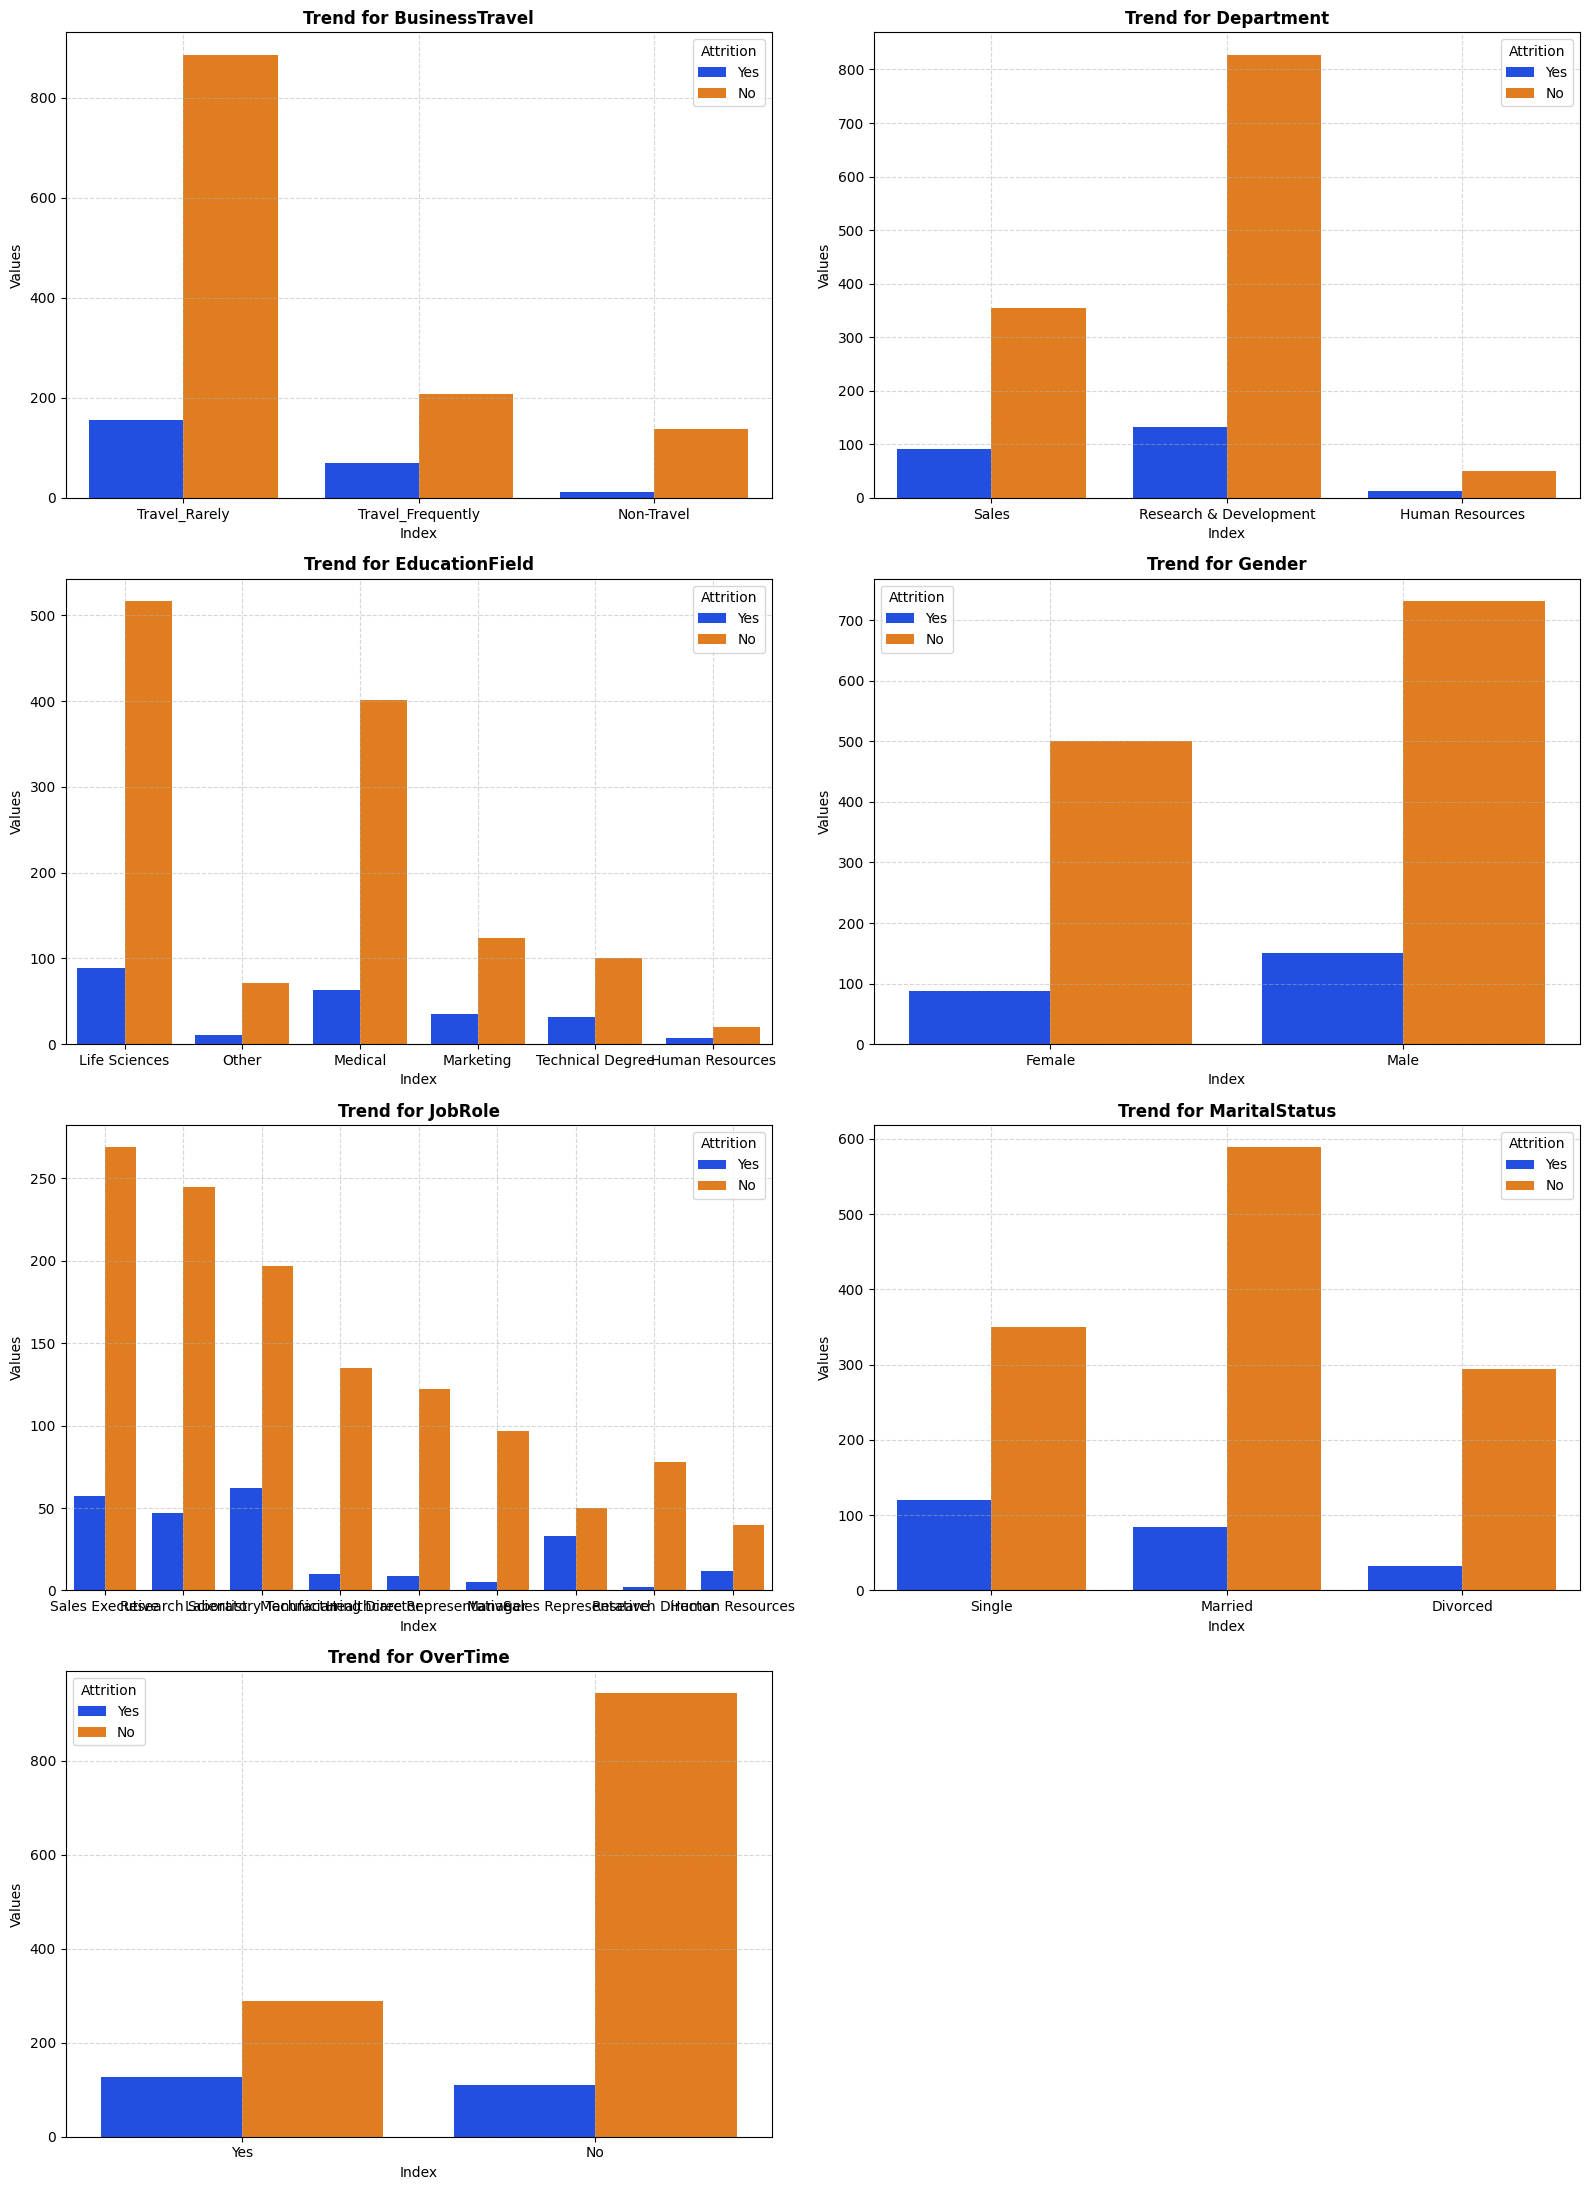

In [ ]:
#  Initialize the grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 22))

# Flatten the axes array for easy 1D iteration
axes_flat = axes.flatten()

#  Loop through columns and axes simultaneously
for index, col_name in enumerate(cat_cols_without_attr):
    ax = axes_flat[index]
    
    # Generate the plot on the specific axis
    sns.countplot(data=employee_df,x=col_name,hue="Attrition",palette="bright", ax=ax)
    
    # Customize the individual subplot
    ax.set_title(f'Trend for {col_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Index', fontsize=10)
    ax.set_ylabel('Values', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

# Hide any unused/empty subplots in the grid
for remaining_index in range(len(cat_cols_without_attr), len(axes_flat)):
    fig.delaxes(axes_flat[remaining_index])

#  Optimize spacing and display
plt.tight_layout()
plt.show()

## Checking unique values in each Categorical column

In [16]:
for col in categorical_cols:
  print("\n",col,"->",employee_df[col].unique())


 Attrition -> <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

 BusinessTravel -> <ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

 Department -> <ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

 EducationField -> <ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

 Gender -> <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

 JobRole -> <ArrowStringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

 MaritalStatus -> <ArrowStringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

 OverTime -> <ArrowStringArray>
['

In [17]:
corr_matrix = employee_df.corr(numeric_only=True)

## Correlation Analysis

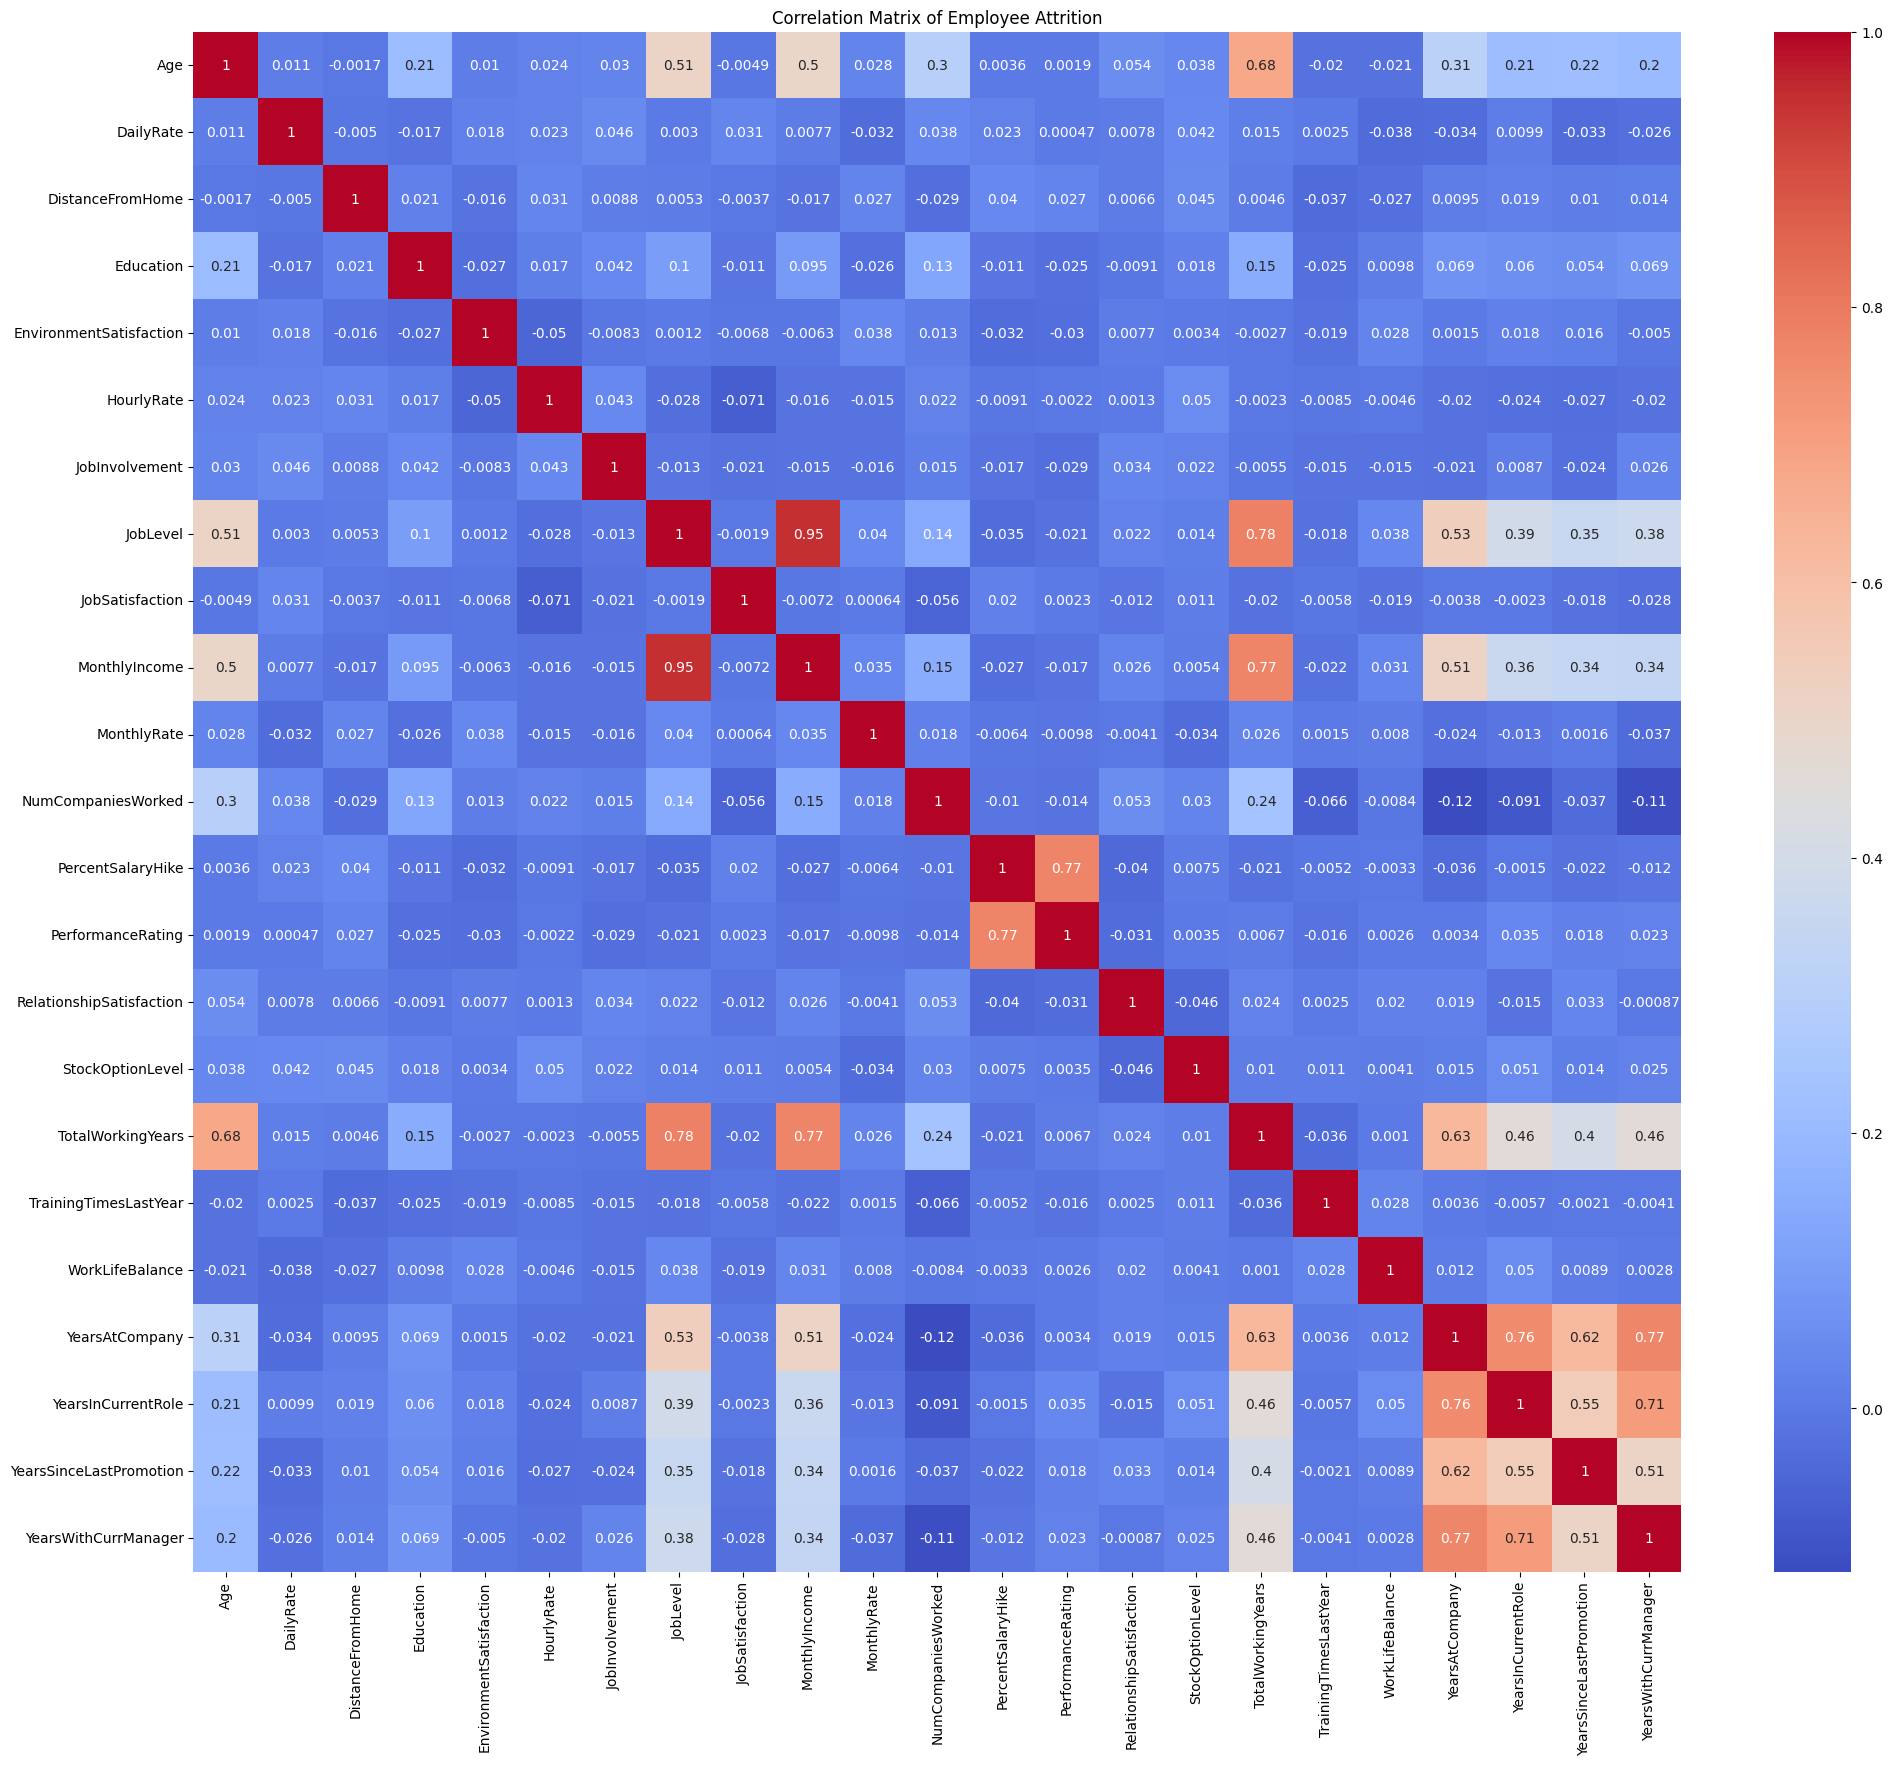

In [18]:
plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix,cmap="coolwarm",annot=True)
plt.title("Correlation Matrix of Employee Attrition")
plt.show()